In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [4]:
# Load datasets
customer_orders = pd.read_csv('customer_orders.csv')
payments = pd.read_csv('payments.csv')

In [6]:
# Ensure date fields are in datetime format
customer_orders['order_date'] = pd.to_datetime(customer_orders['order_date'])

In [8]:
# Get first purchase date for each customer
customer_first_purchase = customer_orders.groupby('customer_id')['order_date'].min().reset_index()
customer_first_purchase.columns = ['customer_id', 'first_purchase_date']

In [10]:
# Merge with original data
customer_orders = pd.merge(customer_orders, customer_first_purchase, on='customer_id')

In [12]:
# Extract acquisition cohort (year-month of first purchase)
customer_orders['cohort'] = customer_orders['first_purchase_date'].dt.to_period('M')

In [14]:
# Calculate period number for each order (months since first purchase)
customer_orders['order_month'] = customer_orders['order_date'].dt.to_period('M')
customer_orders['period_number'] = (customer_orders['order_month'] - customer_orders['cohort']).apply(lambda x: x.n)

In [16]:
# Create cohort analysis
cohort_data = customer_orders.groupby(['cohort', 'period_number'])['customer_id'].nunique().reset_index()
cohort_counts = customer_orders.groupby('cohort')['customer_id'].nunique().reset_index()
cohort_counts.columns = ['cohort', 'customer_count']
cohort_data = pd.merge(cohort_data, cohort_counts, on='cohort')
cohort_data['retention_rate'] = cohort_data['customer_id'] / cohort_data['customer_count']

In [18]:
# Pivot for visualization
cohort_pivot = cohort_data.pivot_table(index='cohort', columns='period_number', values='retention_rate')

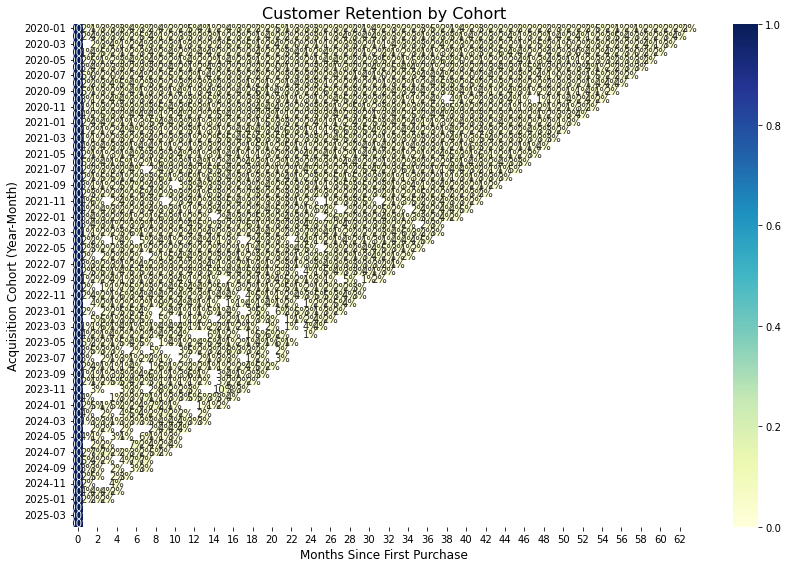

In [20]:
# Create retention heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cohort_pivot, annot=True, fmt='.0%', cmap='YlGnBu', vmin=0, vmax=1)
plt.title('Customer Retention by Cohort', fontsize=16)
plt.xlabel('Months Since First Purchase', fontsize=12)
plt.ylabel('Acquisition Cohort (Year-Month)', fontsize=12)
plt.tight_layout()
plt.savefig('customer_retention_heatmap.png', dpi=300)

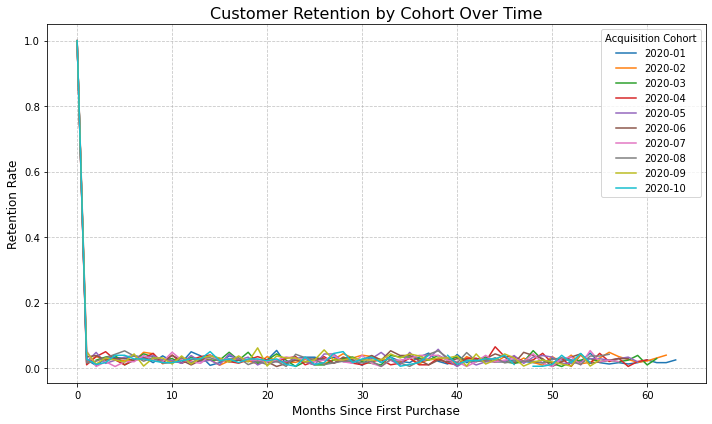

In [22]:
# Create retention line chart
plt.figure(figsize=(10, 6))
for i, cohort in enumerate(cohort_pivot.index):
    if i < 10:  # Display only the first 10 cohorts for clarity
        plt.plot(cohort_pivot.columns, cohort_pivot.loc[cohort], label=str(cohort))

plt.title('Customer Retention by Cohort Over Time', fontsize=16)
plt.xlabel('Months Since First Purchase', fontsize=12)
plt.ylabel('Retention Rate', fontsize=12)
plt.legend(title='Acquisition Cohort')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('customer_retention_line_chart.png', dpi=300)

In [24]:
# Calculate average retention rates by period number
avg_retention = cohort_pivot.mean()

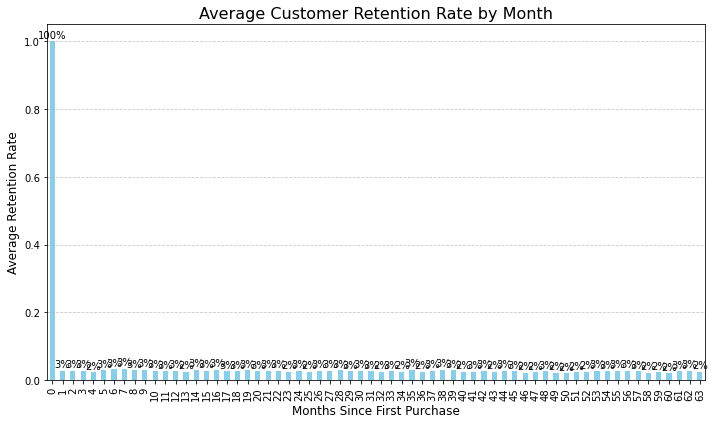

In [26]:
# Create average retention bar chart
plt.figure(figsize=(10, 6))
avg_retention.plot(kind='bar', color='skyblue')
plt.title('Average Customer Retention Rate by Month', fontsize=16)
plt.xlabel('Months Since First Purchase', fontsize=12)
plt.ylabel('Average Retention Rate', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7, axis='y')
plt.tight_layout()

for i, v in enumerate(avg_retention):
    plt.text(i, v + 0.01, f'{v:.0%}', ha='center')

plt.savefig('average_retention_bar_chart.png', dpi=300)